# Project 3 - Loan Eligibility Predictor

## Banks receive thousands of loan applications every year. Manual evaluation is time-consuming and may lead to inconsistent decisions. This project develops a machine learning model that predicts whether an applicant is likely to be approved for a loan based on demographic and financial information. 

## Uploading and Reading the data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Loan_Data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [3]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [4]:
df.shape

(614, 13)

In [5]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

## EDA

In [6]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

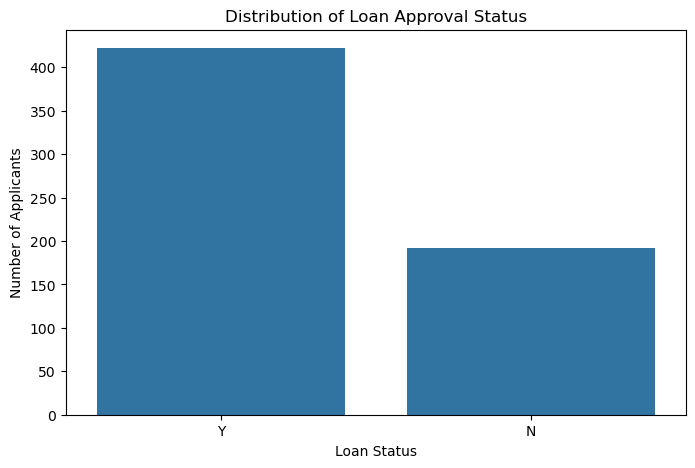

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='Loan_Status', data=df, )
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
plt.title('Distribution of Loan Approval Status')

plt.show()

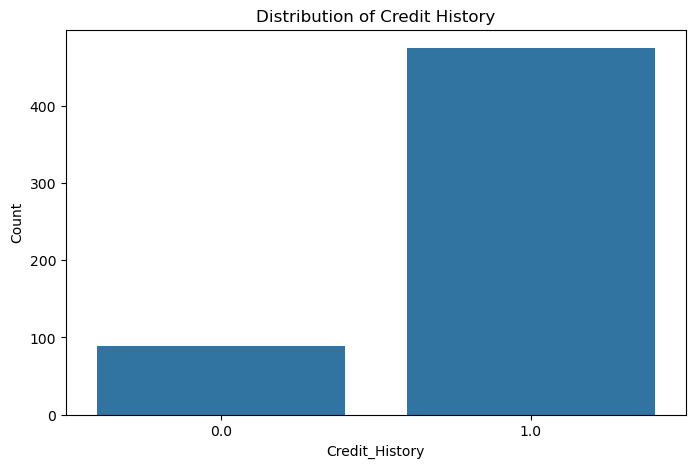

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Credit_History', data=df)
plt.xlabel('Credit_History')
plt.ylabel('Count')
plt.title('Distribution of Credit History')

plt.show()

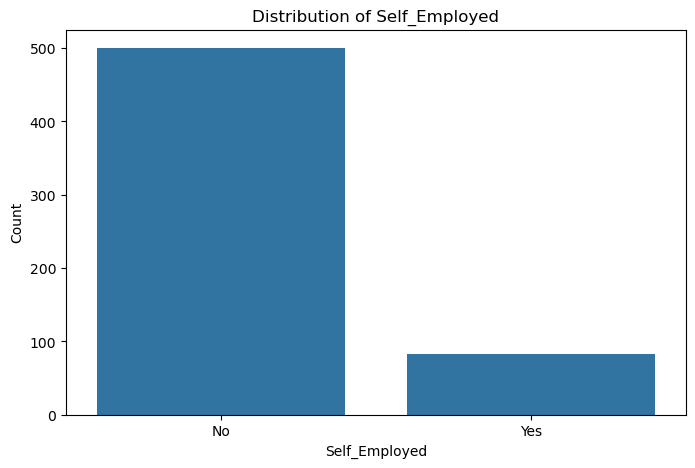

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Self_Employed', data=df)
plt.xlabel('Self_Employed')
plt.ylabel('Count')
plt.title('Distribution of Self_Employed')

plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17744\3352885151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Property_Area', data=df, palette='viridis')


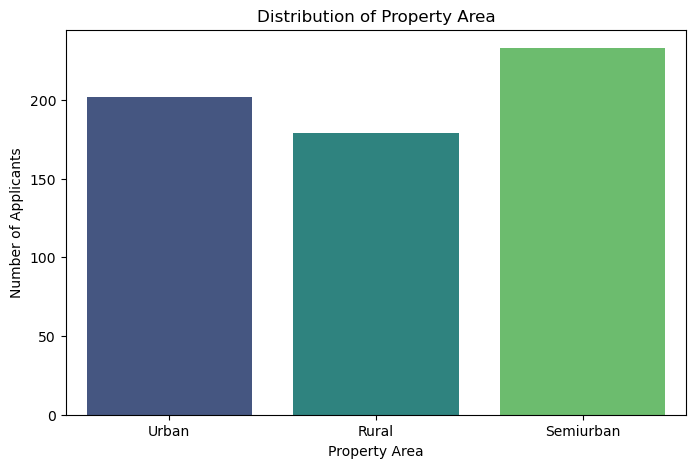

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='Property_Area', data=df, palette='viridis')

plt.xlabel('Property Area')
plt.ylabel('Number of Applicants')
plt.title('Distribution of Property Area')

plt.show()

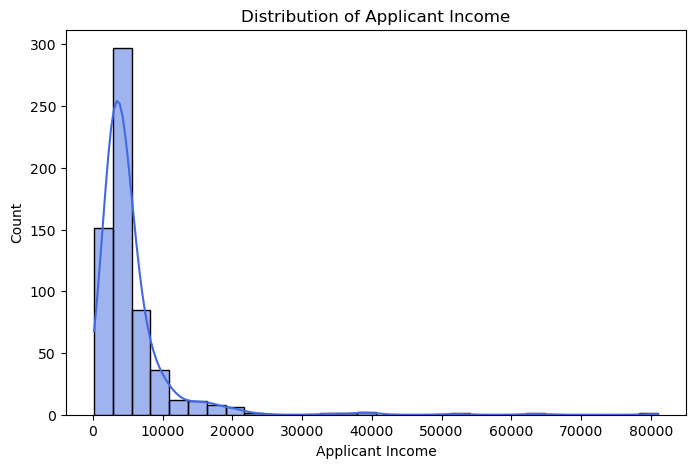

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True, color='royalblue')

plt.xlabel('Applicant Income')
plt.ylabel('Count')
plt.title('Distribution of Applicant Income')

plt.show()

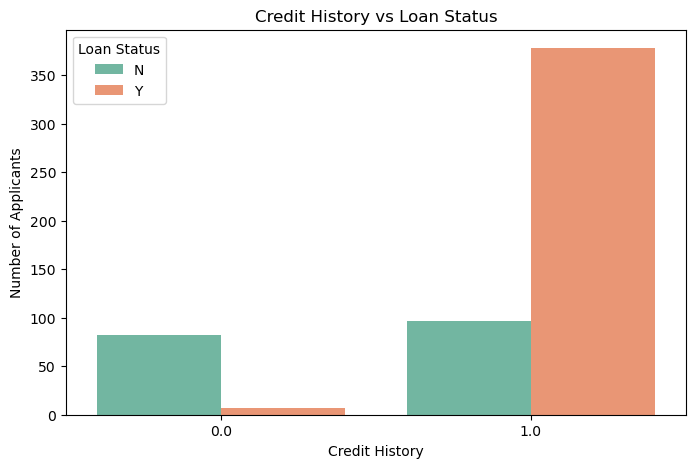

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='Set2')

plt.xlabel('Credit History')
plt.ylabel('Number of Applicants')
plt.title('Credit History vs Loan Status')

plt.legend(title='Loan Status')

plt.show()

# Those who had credit score = 1 had higher chances for Loan approval. (IMPORTANT)

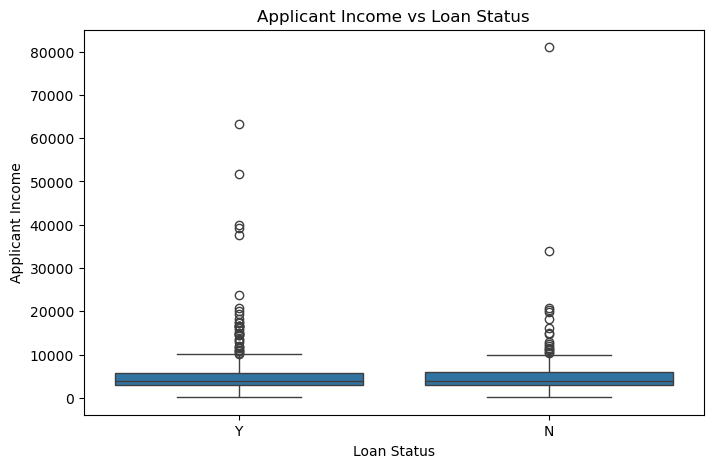

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)

plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.title('Applicant Income vs Loan Status')

plt.show()

# This shows their are many outliers in Applicant income, like most applicants are less than 10000 but their are still many out of normal range

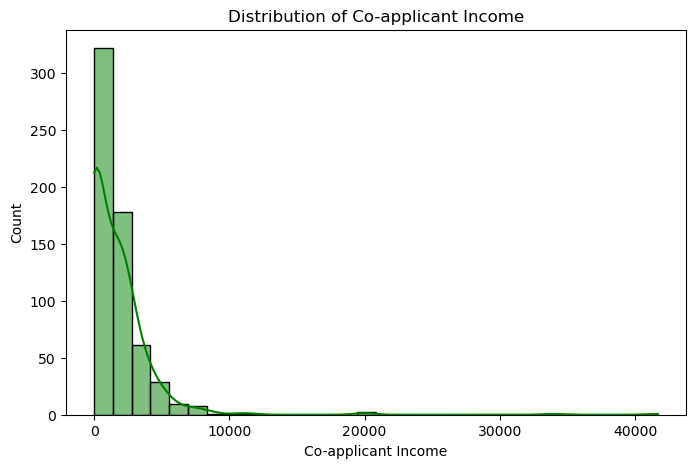

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['CoapplicantIncome'], bins=30, kde=True, color='green')

plt.xlabel('Co-applicant Income')
plt.ylabel('Count')
plt.title('Distribution of Co-applicant Income')

plt.show()

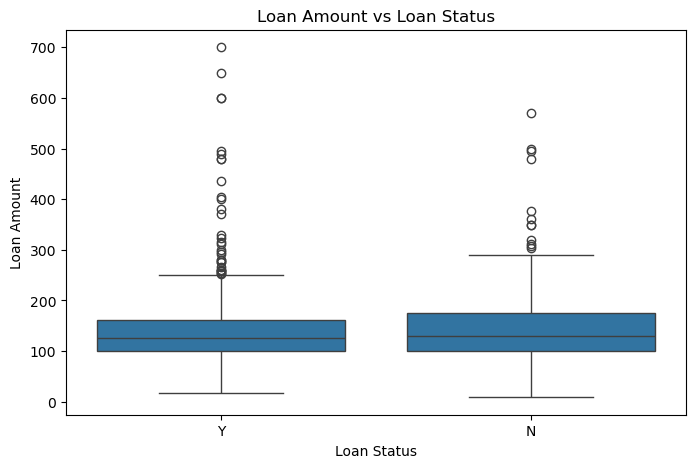

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount vs Loan Status')
plt.show()

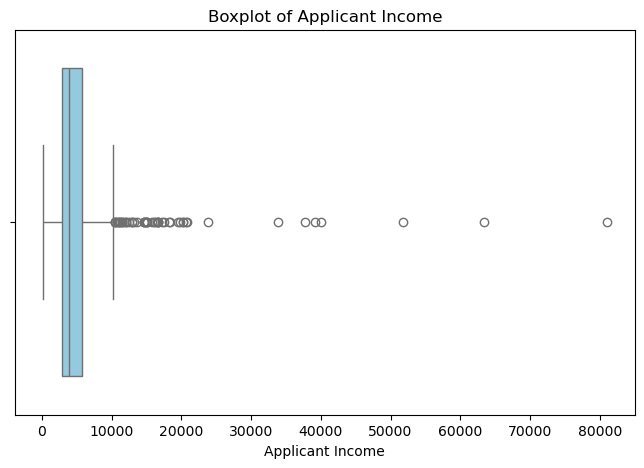

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['ApplicantIncome'], color='skyblue')

plt.xlabel('Applicant Income')
plt.title('Boxplot of Applicant Income')

plt.show()

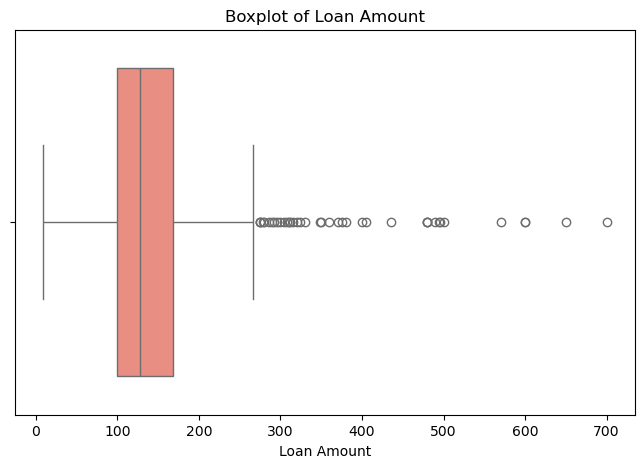

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['LoanAmount'], color='salmon')

plt.xlabel('Loan Amount')
plt.title('Boxplot of Loan Amount')

plt.show()

In [18]:
#Feature Engneering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

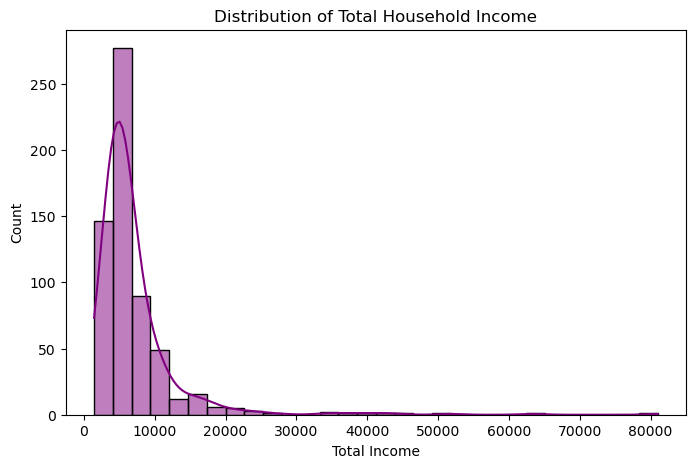

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalIncome'], bins=30, kde=True, color='purple')

plt.xlabel('Total Income')
plt.ylabel('Count')
plt.title('Distribution of Total Household Income')

plt.show()

### Key Insights from EDA

• Most applicants were male.

• Most loans were approved.

• Credit History showed the strongest relationship with loan approval.

• Applicant Income is highly right-skewed.

• Loan Amount contains several outliers.

• Urban and Semiurban applicants have slightly higher approval rates.

• Household income appears more meaningful than applicant income alone.

## Data Cleaning

In [20]:
df.drop('Loan_ID', axis=1, inplace=True)

In [21]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
dtype: int64

In [22]:
# fill missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [23]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
dtype: int64

In [24]:
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
TotalIncome          float64
dtype: object

In [25]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [26]:
# Income to Loan Ratio
df['Income_to_Loan_Ratio'] = df['TotalIncome'] / df['LoanAmount']

# Income per Dependent
df['Income_Per_Dependent'] = df['TotalIncome'] / (df['Dependents'] + 1)

# Monthly Loan Burden
df['Monthly_Loan_Burden'] = df['LoanAmount'] / df['Loan_Amount_Term']

In [27]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(0).astype(int)

In [28]:
df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
).astype(int)

In [29]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [30]:
df['Income_to_Loan_Ratio'] = df['Income_to_Loan_Ratio'].fillna(df['Income_to_Loan_Ratio'].median())
df['Monthly_Loan_Burden'] = df['Monthly_Loan_Burden'].fillna(df['Monthly_Loan_Burden'].median())

In [31]:
df.isnull().sum()

Gender                  0
Married                 0
Dependents              0
Education               0
Self_Employed           0
ApplicantIncome         0
CoapplicantIncome       0
LoanAmount              0
Loan_Amount_Term        0
Credit_History          0
Property_Area           0
Loan_Status             0
TotalIncome             0
Income_to_Loan_Ratio    0
Income_Per_Dependent    0
Monthly_Loan_Burden     0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                614 non-null    object 
 1   Married               614 non-null    object 
 2   Dependents            614 non-null    int32  
 3   Education             614 non-null    object 
 4   Self_Employed         614 non-null    object 
 5   ApplicantIncome       614 non-null    int64  
 6   CoapplicantIncome     614 non-null    float64
 7   LoanAmount            614 non-null    float64
 8   Loan_Amount_Term      614 non-null    int32  
 9   Credit_History        614 non-null    int32  
 10  Property_Area         614 non-null    object 
 11  Loan_Status           614 non-null    object 
 12  TotalIncome           614 non-null    float64
 13  Income_to_Loan_Ratio  614 non-null    float64
 14  Income_Per_Dependent  614 non-null    float64
 15  Monthly_Loan_Burden   6

In [33]:
df.duplicated().sum()

0

In [34]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_to_Loan_Ratio,Income_Per_Dependent,Monthly_Loan_Burden
0,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y,5849.0,41.426540,5849.0,0.365278
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N,6091.0,47.585938,3045.5,0.355556
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y,3000.0,45.454545,3000.0,0.183333
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y,4941.0,41.175000,4941.0,0.333333
4,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y,6000.0,42.553191,6000.0,0.391667


Data Cleaning

 Removed unnecessary columns (Loan_ID) ; 
 Checked missing values ; 
 Imputed categorical missing values using mode ; 
 Imputed numerical missing values using median/mode ; 
 Converted data types ; 
 Checked duplicate records ; 
 Final dataset verification 

In [35]:
df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1, inplace=True)

In [36]:
categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area'
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [37]:
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

In [38]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Stratify -> It ensures that the proportion of approved and rejected loans remains similar in both the training and testing datasets.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               614 non-null    int32  
 1   LoanAmount               614 non-null    float64
 2   Loan_Amount_Term         614 non-null    int32  
 3   Credit_History           614 non-null    int32  
 4   Loan_Status              614 non-null    int64  
 5   TotalIncome              614 non-null    float64
 6   Income_to_Loan_Ratio     614 non-null    float64
 7   Income_Per_Dependent     614 non-null    float64
 8   Monthly_Loan_Burden      614 non-null    float64
 9   Gender_Male              614 non-null    bool   
 10  Married_Yes              614 non-null    bool   
 11  Education_Not Graduate   614 non-null    bool   
 12  Self_Employed_Yes        614 non-null    bool   
 13  Property_Area_Semiurban  614 non-null    bool   
 14  Property_Area_Urban      6

## Implimentation of ML

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [43]:
X.isnull().sum()

Dependents                 0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
TotalIncome                0
Income_to_Loan_Ratio       0
Income_Per_Dependent       0
Monthly_Loan_Burden        0
Gender_Male                0
Married_Yes                0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

In [44]:
# Create Logistic Regression model
lr = LogisticRegression(class_weight='balanced' , random_state=42)

# Train the model
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [45]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

feature_importance

,Feature,Coefficient
3,Credit_History,1.238030
12,Property_Area_Semiurban,0.352183
9,Married_Yes,0.266828
10,Education_Not Graduate,-0.178612
2,Loan_Amount_Term,-0.111600
7,Monthly_Loan_Burden,-0.097975
11,Self_Employed_Yes,-0.065153
4,TotalIncome,-0.062841
8,Gender_Male,-0.059202
6,Income_Per_Dependent,-0.052747


In [46]:
# Predict on test data
y_pred_lr = lr.predict(X_test)

In [47]:
print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Accuracy : 0.8211382113821138
Precision: 0.8620689655172413
Recall   : 0.8823529411764706
F1 Score : 0.872093023255814


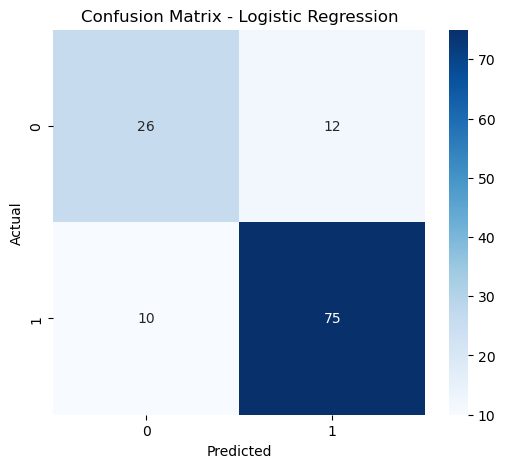

In [48]:
# CONFUSION MATRIX
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123



In [50]:
# CROSS VALIDATION
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


"""
Cross-validation was performed using a Pipeline to ensure that feature scaling was applied independently within each fold, preventing data leakage
and providing a more reliable estimate of model performance.
"""

Cross Validation Scores: [0.81300813 0.76422764 0.7804878  0.85365854 0.81147541]
Mean CV Accuracy: 0.8045715047314406


'\nCross-validation was performed using a Pipeline to ensure that feature scaling was applied independently within each fold, preventing data leakage\nand providing a more reliable estimate of model performance.\n'

In [51]:
# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best F1 Score:",grid.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best F1 Score: 0.8669676802055782


In [52]:
best_lr = grid.best_estimator_

In [53]:
y_pred_best = best_lr.predict(X_test)

In [54]:
probabilities = best_lr.predict_proba(X_test)

print(probabilities[:10])

[[0.75338417 0.24661583]
 [0.28333384 0.71666616]
 [0.37463478 0.62536522]
 [0.34256266 0.65743734]
 [0.2807524  0.7192476 ]
 [0.33777339 0.66222661]
 [0.28636493 0.71363507]
 [0.29431172 0.70568828]
 [0.4043229  0.5956771 ]
 [0.36509117 0.63490883]]


### Naive Bayes

In [55]:
# Create model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

GaussianNB()

In [56]:
y_pred_nb = nb.predict(X_test)

In [57]:
print("Gaussian Naive Bayes Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Gaussian Naive Bayes Results
----------------------------------------
Accuracy : 0.8455284552845529
Precision: 0.83
Recall   : 0.9764705882352941
F1 Score : 0.8972972972972973


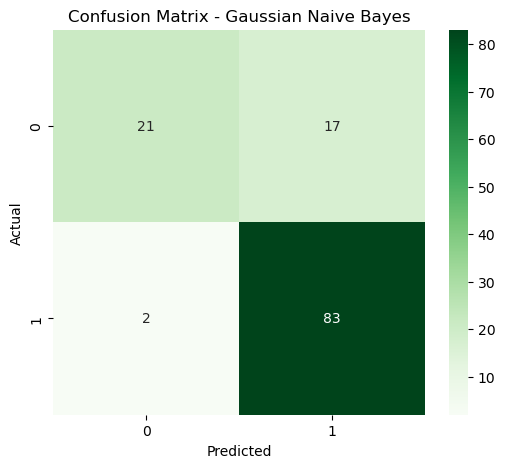

In [58]:
# CONFUSION MATRIX
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_nb),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

In [59]:
#CLASSIFICATION REPORT
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.91      0.55      0.69        38
           1       0.83      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.87      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



### Comparison b/w both models

In [60]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    "Gaussian Naive Bayes": [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_nb)
    ]
})

comparison

,Metric,Logistic Regression,Gaussian Naive Bayes
0,Accuracy,0.821138,0.845528
1,Precision,0.862069,0.830000
2,Recall,0.882353,0.976471
3,F1 Score,0.872093,0.897297


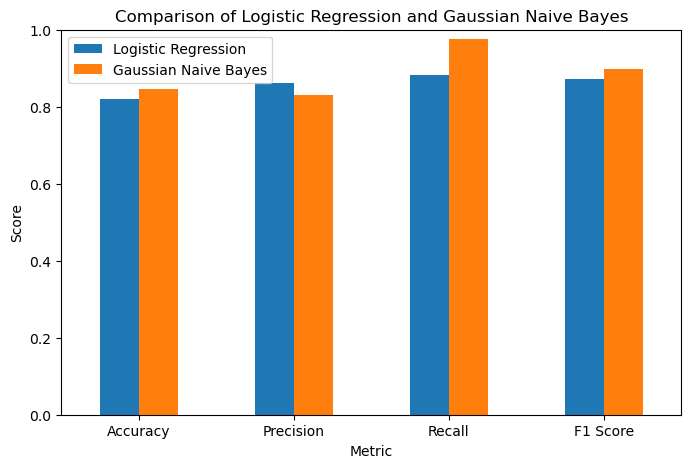

In [61]:
# BAR GRAPH FOR COMPARISION
comparison.set_index("Metric").plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Comparison of Logistic Regression and Gaussian Naive Bayes")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.show()

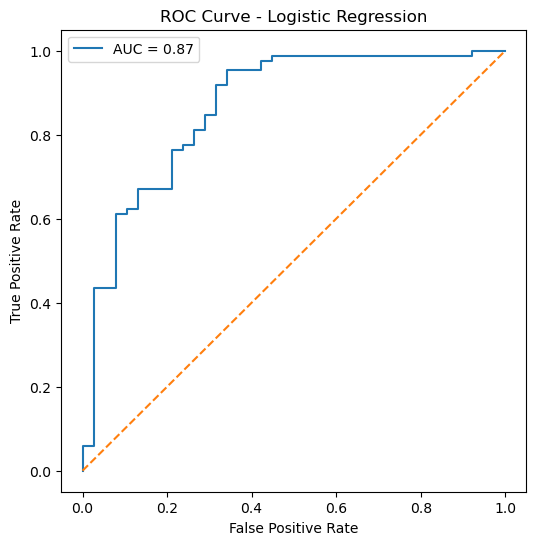

In [62]:
# ROC AND AUC CURVE
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

# RANDOM FOREST

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,       
    min_samples_leaf=3,   # small guard against overfitting since depth is unlimited
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy : 0.8373983739837398
Precision: 0.8823529411764706
Recall   : 0.8823529411764706
F1 Score : 0.8823529411764706

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        38
           1       0.88      0.88      0.88        85

    accuracy                           0.84       123
   macro avg       0.81      0.81      0.81       123
weighted avg       0.84      0.84      0.84       123



In [64]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Random Forest feature importance:")
print(rf_importance)
print()
print("Logistic Regression feature importance (for comparison):")
print(feature_importance)

Random Forest feature importance:
                    Feature  Importance
3            Credit_History    0.261546
6      Income_Per_Dependent    0.125855
5      Income_to_Loan_Ratio    0.122781
4               TotalIncome    0.119060
1                LoanAmount    0.107486
7       Monthly_Loan_Burden    0.105193
12  Property_Area_Semiurban    0.034664
0                Dependents    0.028433
2          Loan_Amount_Term    0.022326
9               Married_Yes    0.019126
10   Education_Not Graduate    0.018113
13      Property_Area_Urban    0.014143
11        Self_Employed_Yes    0.010762
8               Gender_Male    0.010513

Logistic Regression feature importance (for comparison):
                    Feature  Coefficient
3            Credit_History     1.238030
12  Property_Area_Semiurban     0.352183
9               Married_Yes     0.266828
10   Education_Not Graduate    -0.178612
2          Loan_Amount_Term    -0.111600
7       Monthly_Loan_Burden    -0.097975
11        Self_Employ

In [65]:
def predict_loan_rf(applicant):
    prediction = rf.predict(applicant)[0]
    probability = rf.predict_proba(applicant)[0][1]

    if probability >= 0.80:
        risk = "Low Risk"
    elif probability >= 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    print(f"Approval Probability: {probability*100:.2f}%")
    print("Prediction:", "Loan Approved" if probability >= 0.5 else "Loan Rejected")
    print(f"Risk Category: {risk}")

In [66]:
# FINAL FUNCTION FOR PREDICTION OF LOAN APPROVAL

def predict_loan(applicant):

    # Scale the input
    applicant = scaler.transform(applicant)

    # Predict
    prediction = best_lr.predict(applicant)[0]

    # Get approval probability
    probability = best_lr.predict_proba(applicant)[0][1]

    # Assign Risk Category
    if probability >= 0.80:
        risk = "Low Risk"
    elif probability >= 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    # Print Results
    print(f"Approval Probability: {probability*100:.2f}%")

    if prediction == 1:
        print("Prediction: Loan Approved")
    else:
        print("Prediction: Loan Rejected")

    print(f"Risk Category: {risk}")

## Testing

In [67]:
new_customer = [[
     0,     # Dependents
    150,    # Loan Amount
    360,    # Loan Term
    1,      # Credit History
    9500,   # Total Income
    63.3,   # Income_to_Loan_Ratio
    9500,   # Income_Per_Dependent
    0.42,    # Monthly_Loan_Burden
    1,      # Gender
    1,      # Married
    0,      # Education
    0,      # Self Employed
    1,      # Property Area semiurban
    0       # Property Area urban 
]]

predict_loan_rf(new_customer)

Approval Probability: 40.99%
Prediction: Loan Rejected
Risk Category: High Risk


In [68]:
new_customer = [[
     0,     # Dependents
    150,    # Loan Amount
    360,    # Loan Term
    1,      # Credit History
    9500,   # Total Income
    63.3,   # Income_to_Loan_Ratio
    9500,   # Income_Per_Dependent
    0.42,    # Monthly_Loan_Burden
    1,      # Gender
    1,      # Married
    0,      # Education
    0,      # Self Employed
    1,      # Property Area semiurban
    0       # Property Area urban 
]]

predict_loan(new_customer)

Approval Probability: 70.48%
Prediction: Loan Approved
Risk Category: Medium Risk


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [69]:
# STRESS TEST: low income + high loan amount + GOOD credit history
# (same format/column order as your original new_customer test)

stress_test_customer = [[
    0,      # Dependents
    400,    # Loan Amount (high)
    360,    # Loan Term
    1,      # Credit History (good)
    2000,   # Total Income (low)
    5.0,    # Income_to_Loan_Ratio (2000/400 = 5, much lower than your original 63.3)
    2000,   # Income_Per_Dependent
    1.11,   # Monthly_Loan_Burden (400/360)
    1,      # Gender
    1,      # Married
    0,      # Education
    0,      # Self Employed
    1,      # Property Area semiurban
    0       # Property Area urban
]]

predict_loan(stress_test_customer)

Approval Probability: 71.41%
Prediction: Loan Approved
Risk Category: Medium Risk


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [70]:
# STRESS TEST: high income + low loan amount + BAD credit history
# Tests whether the model will still reject purely due to bad credit,
# even when affordability is clearly excellent

stress_test_bad_credit = [[
    0,       # Dependents
    80,      # Loan Amount (low)
    360,     # Loan Term
    0,       # Credit History (BAD)
    15000,   # Total Income (high)
    187.5,   # Income_to_Loan_Ratio (15000/80)
    15000,   # Income_Per_Dependent
    0.22,    # Monthly_Loan_Burden (80/360)
    1,       # Gender
    1,       # Married
    0,       # Education
    0,       # Self Employed
    1,       # Property Area semiurban
    0        # Property Area urban
]]

predict_loan(stress_test_bad_credit)

Approval Probability: 33.56%
Prediction: Loan Rejected
Risk Category: High Risk


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [71]:
print("Low income / high loan / GOOD credit:")
predict_loan_rf(stress_test_customer)

print("\nHigh income / low loan / BAD credit:")
predict_loan_rf(stress_test_bad_credit)

Low income / high loan / GOOD credit:
Approval Probability: 45.57%
Prediction: Loan Rejected
Risk Category: High Risk

High income / low loan / BAD credit:
Approval Probability: 44.38%
Prediction: Loan Rejected
Risk Category: High Risk


In [72]:
print("Low income / high loan / GOOD credit:")
predict_loan(stress_test_customer)

print("\nHigh income / low loan / BAD credit:")
predict_loan(stress_test_bad_credit)

Low income / high loan / GOOD credit:
Approval Probability: 71.41%
Prediction: Loan Approved
Risk Category: Medium Risk

High income / low loan / BAD credit:
Approval Probability: 33.56%
Prediction: Loan Rejected
Risk Category: High Risk


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
